# CNOT baseline

This notebook loads the results from ft mode and trel mode from Ethan Lake's code for quantum memory local decoder.

### ft mode

In [1]:
# initial scan
import numpy as np
import re
from pathlib import Path

data_dir = Path("../results/baseline/ft/20260617")
expected_p_values = np.array([0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])
expected_L_values = np.array([5, 7, 9, 13, 19])
expected_repeats = 5

result_paths = sorted(data_dir.rglob("2d_Ft*.txt"))
if not result_paths:
    raise FileNotFoundError(f"No Ft result files found under {data_dir.resolve()}. Run initial_scan.sh first, or change data_dir to another scan folder.")

def parse_scalar(text, name, path):
    match = re.search(rf"^{name}\s*=\s*(?:\[([^\]]+)\]|([^\s#]+))\s*$", text, re.MULTILINE)
    if match is None:
        raise ValueError(f"Could not parse {name} from {path}")
    value_text = match.group(1) or match.group(2)
    values = np.fromstring(value_text, sep=" ")
    return float(values[0]) if values.size else float(value_text)

def load_cnot_ft_result(path):
    text = path.read_text()
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if l_match is None or p_match is None:
        raise ValueError(f"Could not parse L/p params from {path}")

    ft = parse_scalar(text, "Ft", path)
    trials = parse_scalar(text, "trials", path)
    return int(l_match.group(1)), float(p_match.group(1)), ft, trials

all_records = [load_cnot_ft_result(path) for path in result_paths]
L_values = expected_L_values
p_values = expected_p_values

def is_requested_record(record):
    cur_l, cur_p, *_ = record
    return np.any(L_values == cur_l) and np.any(np.isclose(p_values, cur_p))

records = [record for record in all_records if is_requested_record(record)]
ignored_count = len(all_records) - len(records)
if not records:
    raise ValueError("No Ft result files matched the requested expected_L_values/expected_p_values.")

Ft_successes = np.zeros((len(L_values), len(p_values)))
Ft_trials = np.zeros_like(Ft_successes)
Ft_rep_count = np.zeros_like(Ft_successes, dtype=int)

for cur_l, cur_p, ft, trials in records:
    l_idx = np.where(L_values == cur_l)[0][0]
    p_idx = np.where(np.isclose(p_values, cur_p))[0][0]
    Ft_successes[l_idx, p_idx] += ft * trials
    Ft_trials[l_idx, p_idx] += trials
    Ft_rep_count[l_idx, p_idx] += 1

missing_mask = Ft_rep_count == 0
if np.any(missing_mask):
    missing = [(int(L_values[i]), float(p_values[j])) for i, j in np.argwhere(missing_mask)]
    print(f"Warning: missing requested Ft data for these (L, p) points; leaving them as NaN: {missing}")

nonzero_rep_counts = Ft_rep_count[Ft_rep_count > 0]

if np.unique(nonzero_rep_counts).size > 1:
    print("Warning: not every (L, p) point has the same number of repeats.")

if expected_repeats is not None and np.any(nonzero_rep_counts != expected_repeats):
    print(f"Warning: expected {expected_repeats} repeats per (L, p) point.")

Ft_mean = np.divide(Ft_successes, Ft_trials, out=np.full_like(Ft_successes, np.nan), where=Ft_trials > 0)
error_rate = 1 - Ft_mean
error_rate_variance = np.divide(error_rate * (1 - error_rate), Ft_trials, out=np.full_like(error_rate, np.nan), where=Ft_trials > 0)
error_rate_error = np.sqrt(error_rate_variance)

p_grid, L_grid = np.meshgrid(p_values, L_values)
fit_mask = np.isfinite(error_rate) & np.isfinite(error_rate_error) & (error_rate_error > 0)
p = p_grid[fit_mask]
L = L_grid[fit_mask]
rate = error_rate[fit_mask]
rate_error = error_rate_error[fit_mask]

print(f"Loaded {len(records)} requested Ft files; ignored {ignored_count} files outside the requested lists")
print("L values:", L_values)
print("p values:", p_values)
print("repeat counts:\n", Ft_rep_count)


Loaded 225 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019]
repeat counts:
 [[5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5]]


### trel mode

In [2]:
import numpy as np
import re
from pathlib import Path

trel_data_dir = Path("../results/baseline/trel")
trel_p_values = np.array([0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])
trel_L_values = np.array([5, 7, 9, 13, 19])

# Use the aggregate files in trel_data_dir. The repeat_* folders contain the raw repeat inputs.
trel_result_paths = sorted(trel_data_dir.glob("2d_trel_*.txt"))
if not trel_result_paths:
    raise FileNotFoundError(f"No trel result files found under {trel_data_dir.resolve()}.")

def parse_vector(text, name, path):
    match = re.search(rf"^{name}\s*=\s*\[([^\]]+)\]\s*$", text, re.MULTILINE)
    if match is None:
        raise ValueError(f"Could not parse {name} from {path}")
    values = np.fromstring(match.group(1), sep=" ")
    if values.size == 0:
        raise ValueError(f"Parsed empty {name} from {path}")
    return values

def load_trel_result(path):
    text = path.read_text()
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if l_match is None or p_match is None:
        raise ValueError(f"Could not parse L/p params from {path}")

    trel_stats = parse_vector(text, "trel_stats", path)
    samps = parse_vector(text, "samps", path)[0]
    if trel_stats.size < 2:
        raise ValueError(f"Expected trel_stats to contain at least mean/std in {path}")

    mean = trel_stats[0]
    std = trel_stats[1]
    max_trel = trel_stats[2] if trel_stats.size > 2 else np.nan
    sem = std / np.sqrt(samps)
    return int(l_match.group(1)), float(p_match.group(1)), mean, sem, std, max_trel, samps

trel_records = [load_trel_result(path) for path in trel_result_paths]

t_rel = np.full((len(trel_L_values), len(trel_p_values)), np.nan)
t_rel_error = np.full_like(t_rel, np.nan)
t_rel_std = np.full_like(t_rel, np.nan)
t_rel_max = np.full_like(t_rel, np.nan)
trel_samps = np.zeros_like(t_rel)
trel_record_count = np.zeros_like(t_rel, dtype=int)

ignored_trel_count = 0
for cur_l, cur_p, mean, sem, std, max_trel, samps in trel_records:
    l_idx = np.where(trel_L_values == cur_l)[0]
    p_idx = np.where(np.isclose(trel_p_values, cur_p))[0]
    if not l_idx.size or not p_idx.size:
        ignored_trel_count += 1
        continue

    i = l_idx[0]
    j = p_idx[0]
    if trel_record_count[i, j] != 0:
        raise ValueError(f"Duplicate aggregate trel result for L={cur_l}, p={cur_p}")

    t_rel[i, j] = mean
    t_rel_error[i, j] = sem
    t_rel_std[i, j] = std
    t_rel_max[i, j] = max_trel
    trel_samps[i, j] = samps
    trel_record_count[i, j] += 1

missing_trel_mask = trel_record_count == 0
if np.any(missing_trel_mask):
    missing = [(int(trel_L_values[i]), float(trel_p_values[j])) for i, j in np.argwhere(missing_trel_mask)]
    raise ValueError(f"Missing trel data for these (L, p) points: {missing}")

trel_p_grid, trel_L_grid = np.meshgrid(trel_p_values, trel_L_values)
trel_fit_mask = np.isfinite(t_rel) & np.isfinite(t_rel_error) & (t_rel_error > 0)
p_trel = trel_p_grid[trel_fit_mask]
L_trel = trel_L_grid[trel_fit_mask]
trel = t_rel[trel_fit_mask]
trel_error = t_rel_error[trel_fit_mask]

print(f"Loaded {len(trel_records) - ignored_trel_count} requested trel files; ignored {ignored_trel_count} files outside the requested lists")
print("trel L values:", trel_L_values)
print("trel p values:", trel_p_values)
print("trel sample counts:\n", trel_samps.astype(int))


Loaded 45 requested trel files; ignored 0 files outside the requested lists
trel L values: [ 5  7  9 13 19]
trel p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019]
trel sample counts:
 [[1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000]]


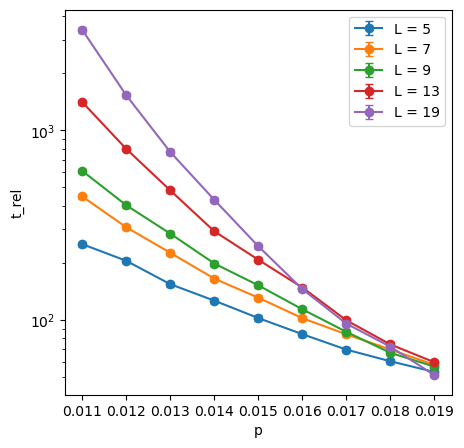

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
for l_idx, cur_l in enumerate(trel_L_values):
    plt.errorbar(trel_p_values, t_rel[l_idx], yerr=t_rel_error[l_idx], fmt='o-', capsize=3, label=f'L = {cur_l}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('t_rel')
plt.legend()
plt.show()